# Fourier Neural Operator (FNO) in Neuromancer

This tutorial demonstrates the use of [FNOs](https://neuraloperator.github.io/dev/theory_guide/fno.html) for solving partial differential equations (PDEs) in the Neuromancer library.

Example inspiration: https://neuraloperator.github.io/dev/auto_examples/models/plot_FNO_darcy.html

<img src="https://neuraloperator.github.io/dev/_images/fourier_layer.jpg" width="600"> 

The Fourier layer just consists of three steps:
- Fourier transform $\mathcal{F}$
- Linear transform on the lower Fourier modes $\mathbf{R}$
- Inverse Fourier transform $\mathcal{F}^{-1}$


### References

<!-- [1] [Raissi, M., Perdikaris, P., & Karniadakis, G. E. (2017). Physics informed deep learning (part i): Data-driven solutions of nonlinear partial differential equations.](https://www.sciencedirect.com/science/article/abs/pii/S0021999118307125)

[2] https://github.com/jdtoscano94/Learning-Python-Physics-Informed-Machine-Learning-PINNs-DeepONets/tree/main

[3] https://github.com/omniscientoctopus/Physics-Informed-Neural-Networks/tree/main -->


## Install (Colab only)
Skip this step when running locally.

In [1]:
# !pip install neuromancer
# !pip install pyDOE

*Note: When running on Colab, one might encounter a pip dependency error with Lida 0.0.10. This can be ignored*

## Imports

In [2]:
# torch and numpy imports
import torch
import torch.nn as nn
import numpy as np

# plotting imports
import matplotlib.pyplot as plt

# filter some user warnings from torch broadcast
import warnings

warnings.filterwarnings("ignore")


In [3]:
# Set default dtype to float32
torch.set_default_dtype(torch.float)
# PyTorch random number generator
torch.manual_seed(1234)

# Random number generators in other libraries
np.random.seed(1234)

# Device configuration
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print(f"Using device: {device}")


Using device: cuda


### Get data of the exact solution
- Data source: (https://zenodo.org/records/12784353)
- Select the number of training grids at a given resolution (16X16)
- Select the number of testing grids at various resolutions (16X16, 32x32)
- Save it in `./data/darcy_flow_small/`

In [4]:
from neuralop.data.datasets import load_darcy_flow_small

In [5]:
train_loader, test_loaders, data_processor = load_darcy_flow_small(
    n_train=20,
    batch_size=4,
    data_root="./data/darcy_flow_small/",
    test_resolutions=[16, 32],
    n_tests=[10, 10],
    test_batch_sizes=[4, 2],
)

Loading test db for resolution 16 with 10 samples 
Loading test db for resolution 32 with 10 samples 


In [6]:
train_dataset = train_loader.dataset
print(train_dataset.__dict__.keys())  # check available keys in dataset


dict_keys(['x', 'y', 'transform_x', 'transform_y'])


In [7]:
for res, test_loader in test_loaders.items():
    print(f"Resolution: {res}")
    # Get first batch
    batch = next(iter(test_loader))
    x = batch["x"]  # Input
    y = batch["y"]  # Output

    print(f"Testing samples for resolution {res} have shape {x.shape[1:]}")


data = train_dataset[0]
x = data["x"]
y = data["y"]

print(f"Training samples have shape {x.shape[1:]}")

# Which sample to view
index = 19

data = train_dataset[index]
data = data_processor.preprocess(data, batched=False)


Resolution: 16
Testing samples for resolution 16 have shape torch.Size([1, 16, 16])
Resolution: 32
Testing samples for resolution 32 have shape torch.Size([1, 32, 32])
Training samples have shape torch.Size([16, 16])


In [9]:
from neuralop.data.datasets import DarcyDataset

dataset = DarcyDataset(
    root_dir="./data/darcy_flow_small/",
    n_train=20,
    n_tests=[10, 10],
    batch_size=4,
    test_batch_sizes=[4, 2],
    train_resolution=16,
    test_resolutions=[16, 32],
    download=True,
)

# train_dataset = dataset.train_dataset
# print(dataset).__dict__.keys()  # check available keys in dataset

Loading test db for resolution 16 with 10 samples 
Loading test db for resolution 32 with 10 samples 


In [ ]:
train_db = dataset._train_db
print((train_db.__dict__.keys()))  # check available keys in dataset
# Get dataset length and grid resolution
n_train = len(train_db)
index = 0
x_sample = train_db[index]["x"]  # shape (1, 16, 16) for your data
res_x, res_y = x_sample.shape[-2:]  # grid resolution

print(f"length of training set = {n_train}")
print(f"resolution = {res_x}")
print(f"shape of grid = [{res_x}, {res_y}]")


dict_keys(['x', 'y', 'transform_x', 'transform_y'])
length of training set = 20
resolution = 16
shape of grid = [16, 16]


### Visualise dataset
We can see how the positional embedding adds coordinate information to our input data. This helps the neural operator understand spatial relationships in the data.
Not necessarly need to use this for the input grid

In [13]:
from neuralop.layers.embeddings import GridEmbedding2D

# Which sample to view
index = 0

data = train_db[index]
data = dataset.data_processor.preprocess(data, batched=False)

# The first step of the default FNO model is a grid-based
# positional embedding. We will add it manually here to
# visualize the channels appended by this embedding.
positional_embedding = GridEmbedding2D(in_channels=1)
# At train time, data will be collated with a batch dimension.
# We create a batch dimension to pass into the embedding, then re-squeeze
x = positional_embedding(data["x"].unsqueeze(0)).squeeze(0)
y = data["y"]

/tmp/ipykernel_133235/2254824060.py:16: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


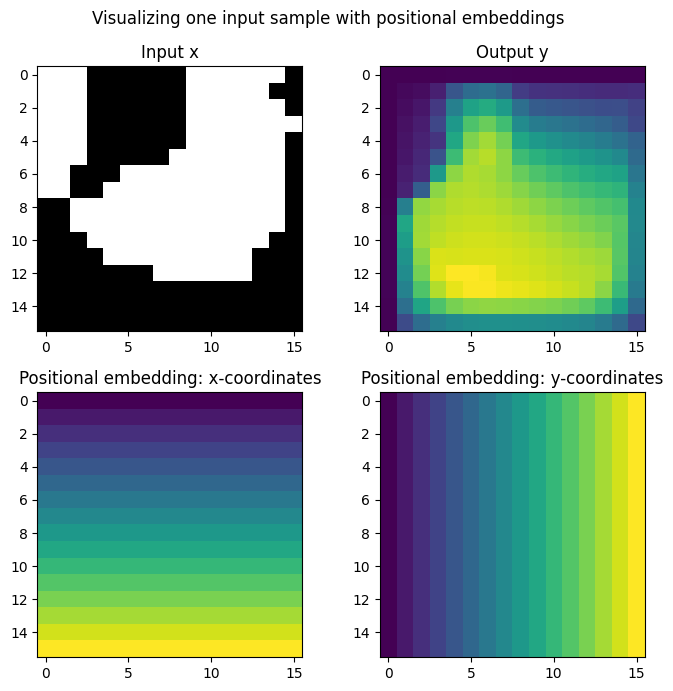

In [14]:
fig = plt.figure(figsize=(7, 7))
ax = fig.add_subplot(2, 2, 1)
ax.imshow(x[0], cmap="gray")
ax.set_title("Input x")
ax = fig.add_subplot(2, 2, 2)
ax.imshow(y.squeeze())
ax.set_title("Output y")
ax = fig.add_subplot(2, 2, 3)
ax.imshow(x[1])
ax.set_title("Positional embedding: x-coordinates")
ax = fig.add_subplot(2, 2, 4)
ax.imshow(x[2])
ax.set_title("Positional embedding: y-coordinates")
fig.suptitle("Visualizing one input sample with positional embeddings", y=0.98)
plt.tight_layout()
fig.show()

In [8]:
def make_fno_grid(nx, nt, requires_grad=False):
    x = torch.linspace(x_min, x_max, nx)
    t = torch.linspace(t_min, t_max, nt)
    X, T = torch.meshgrid(x, t, indexing="ij")
    Y = f_real(X, T)
    # Make grid tensors, FNO needs input shape: [batch_size, in_channels, nx, nt]
    xt_grid = torch.stack([X, T], dim=0).unsqueeze(0).float()  # [1, 2, nx, nt]
    y_grid = Y.unsqueeze(0).unsqueeze(0).float()
    # grad specified? (for training data)
    if requires_grad:
        xt_grid.requires_grad_(True)
    return xt_grid, y_grid


train_nx, train_nt = 32, 32
test_nx, test_nt = 16, 16

# 16x16 training grid
XT_train_grid, Y_train_grid = make_fno_grid(train_nx, train_nt, requires_grad=True)
# 32x32 testing grid
XT_test_grid, Y_test_grid = make_fno_grid(test_nx, test_nt, requires_grad=True)

### Visualise the training and testing grid. Takes a carterisan coordiante system

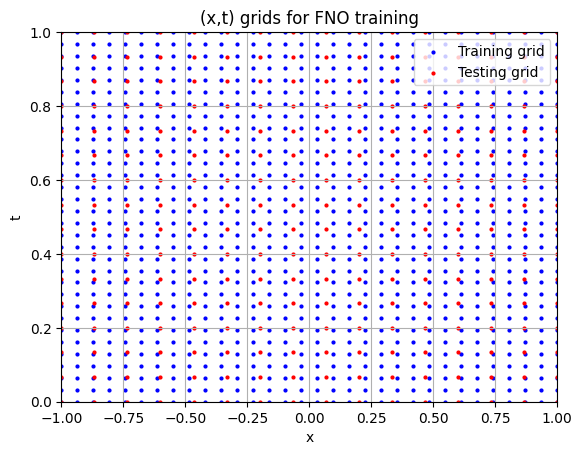

In [9]:
# visualize collocation points for 2D input space (x, t)

# --- Prepare Training Data ---
# Select the x and t coordinates (indices 0 and 1 in dim 1)
# and flatten the last two dimensions (nx * nt) into one vector.
# .squeeze() removes the batch dimension (size 1).
X_train_flat = XT_train_grid.squeeze(0)[0, :, :].flatten()
T_train_flat = XT_train_grid.squeeze(0)[1, :, :].flatten()

# --- Prepare Testing Data (assuming a similar structure) ---
X_test_flat = XT_test_grid.squeeze(0)[0, :, :].flatten()
T_test_flat = XT_test_grid.squeeze(0)[1, :, :].flatten()

# x-bounds: find the min/max ONLY in the testing x-coordinates
x_lb = torch.min(X_test_flat).item()
x_ub = torch.max(X_test_flat).item()

# t-bounds: find the min/max ONLY in the testing t-coordinates
t_lb = torch.min(T_test_flat).item()
t_ub = torch.max(T_test_flat).item()

# --- Plotting ---
plt.figure()
plt.scatter(
    X_train_flat.detach().numpy(),
    T_train_flat.detach().numpy(),
    s=4.0,
    c="blue",
    marker="o",
    label="Training grid",
)
plt.scatter(
    X_test_flat.detach().numpy(),
    T_test_flat.detach().numpy(),
    s=4.0,
    c="red",
    marker="o",
    label="Testing grid",
)

plt.title("(x,t) grids for FNO training")
# Assuming x_lb, x_ub, t_lb, t_ub are defined in your environment
plt.xlim(x_lb, x_ub)
plt.ylim(t_lb, t_ub)
plt.grid(True)
plt.xlabel("x")
plt.ylabel("t")
plt.legend(loc="upper right")
plt.show()
# plt.show(block=True) # Usually only one plt.show() is needed
plt.show(block=True)

### Create Neuromancer datasets for FNO

In [10]:
from neuromancer.dataset import DictDataset

# turn on gradients for FNO
XT_train_grid = XT_train_grid.to(device)
Y_train_grid = Y_train_grid.to(device)

# Prepare FNO training and testing datasets
train_ds_fno = DictDataset(
    {"xt_grid": XT_train_grid, "y_grid": Y_train_grid}, name="fno_train"
)

train_loader_fno = torch.utils.data.DataLoader(
    train_ds_fno, batch_size=1, collate_fn=train_ds_fno.collate_fn, shuffle=False
)

# testing grid
test_ds_fno = DictDataset(
    {"xt_grid": XT_test_grid, "y_grid": Y_test_grid}, name="fno_test"
)
test_loader_fno = torch.utils.data.DataLoader(
    test_ds_fno, batch_size=1, collate_fn=test_ds_fno.collate_fn, shuffle=False
)

### FNO added from neuralop library
May need a wrapper to provide data in the correct format


In [11]:
from neuralop.models import FNO
from neuralop.utils import count_model_params
import sys


# Subclass FNO to remove _metadata from state_dict for compatibility
# fixes the metadata issue when loading/saving models across different PyTorch versions
class FNOWithoutMeta(FNO):
    def state_dict(self, *args, **kwargs):
        state = super().state_dict(*args, **kwargs)
        state.pop("_metadata", None)
        return state

    def load_state_dict(self, state, **kwargs):
        state.pop("_metadata", None)
        return super().load_state_dict(state, **kwargs)


In [ ]:
# FNO to to train the operator for the PDE problem bounded in the PDE domain
fno_model = FNOWithoutMeta(
    n_modes=(8, 8),
    in_channels=1,
    out_channels=1,
    hidden_channels=12,
    projection_channel_ratio=2,
)
fno_model = fno_model.to(device)

# Count and display the number of parameters
n_params = count_model_params(fno_model)
print(f"\nOur model has {n_params} parameters.")
sys.stdout.flush()


Our model has 48157 parameters.


In [13]:
from neuromancer.system import Node

# symbolic wrapper of the FNO
fno_node = Node(fno_model, ["xt_grid"], ["y_hat_fno"], name="fno_model")

In [14]:
print("symbolic inputs  of the fno_node:", fno_node.input_keys)
print("symbolic outputs of the fno_node:", fno_node.output_keys)

symbolic inputs  of the fno_node: ['xt_grid']
symbolic outputs of the fno_node: ['y_hat_fno']


In [15]:
print(device)
print(train_ds_fno.datadict["y_grid"].device)

cuda
cuda:0


In [16]:
# evaluate forward pass on the train data
fno_model_out = fno_node(train_ds_fno.datadict)
fno_model_out["y_hat_fno"].shape

torch.Size([1, 1, 32, 32])

### Generate H1 and L2 loss for loss evaluation 
We use H1 loss for training and L2 loss for evaluation H1 loss is particularly good for PDE problems as it penalizes both function values and gradients

In [18]:
from neuromancer.constraint import Objective, variable

# define L2 loss objective for FNO
y_true = variable("y_grid")  # ground-truth field in your datadict
y_hat_fno = variable("y_hat_fno")  # output from the FNO node


In [ ]:
# Approach 1: Using Constraint from Variables
l2_constraint = (y_hat_fno == y_true) ^ 2  # Eq constraint with quadratic penalty
l2_constraint.key = "l2norm"
l2_constraint.display_name = "l2norm_out"
# l2_obj = l2_constraint.minimize(metric=torch.mean, name="l2_fit")

In [19]:
# Approach 2: Using Objective
residual = y_hat_fno - y_true
l2_obj = Objective(residual**2, metric=torch.mean, name="l2_loss")

In [21]:
# xt_grid
xt = variable("xt_grid")

In [22]:
# define H1 loss objective for FNO
# slice later approach
# ensure grad on every batch (train/dev/test)
# xt = xt.requires_grad_(True)
grad_y_hat_xt = y_hat_fno.grad(xt)  # no allow_unused needed
grad_y_hat_x = grad_y_hat_xt[:, 0, :, :]
grad_y_hat_t = grad_y_hat_xt[:, 1, :, :]

grad_y_true_xt = y_true.grad(xt)  # no allow_unused needed
grad_y_true_x = grad_y_true_xt[:, 0, :, :]
grad_y_true_t = grad_y_true_xt[:, 1, :, :]

In [ ]:
# define H1 loss objective for FNO
# slice first approach
# split xt_grid into spatial and temporal coordinates
x = xt[:, 0, :, :]
t = xt[:, 1, :, :]

# H^1-style constraint: penalize the field mismatch plus spatial/temporal gradients
grad_y_hat_x = y_hat_fno.grad(x)
grad_y_hat_t = y_hat_fno.grad(t)
grad_y_true_x = y_true.grad(x)
grad_y_true_t = y_true.grad(t)

In [ ]:
# Approach 1: Using Constraint from Variables
# Derivative L2 error in x (seminorm)
x_seminorm = (grad_y_hat_x == grad_y_true_x) ^ 2
x_seminorm.key = "h1_x_seminorm"
# Derivative L2 error in t (seminorm)
t_seminorm = (grad_y_hat_t == grad_y_true_t) ^ 2
t_seminorm.key = "h1_t_seminorm"

In [23]:
# Approach 2: Using Objective
# Derivative residuals in x and t
res_grad_y_hat_x = grad_y_hat_x - grad_y_true_x
res_grad_y_hat_t = grad_y_hat_t - grad_y_true_t
h1_residual = residual**2 + res_grad_y_hat_x**2 + res_grad_y_hat_t**2
h1_obj = Objective(h1_residual, metric=torch.mean, name="h1_loss")

### Setup FNO problem and Trainer 

In [24]:
from neuromancer.loss import PenaltyLoss
from neuromancer.problem import Problem

# aggregate list of objective terms and constraints
# objectives_fno = [l2_constraint, x_seminorm, t_seminorm]  # H1 loss for training FNO
objectives_fno = [h1_obj]  # L2 loss for training FNO
constraints_fno = []
# create constrained optimization loss
loss_fno = PenaltyLoss(objectives_fno, constraints_fno)

# construct the FNO supervised training problem
problem_fno = Problem(nodes=[fno_node], loss=loss_fno)

### Show problem FNO

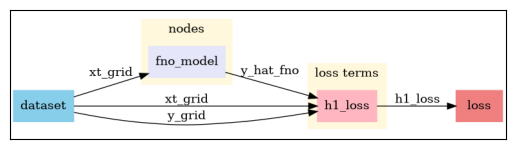

In [25]:
# Visualize the problem graph. Note: must have graphviz installed in the system
problem_fno.show()

### Train FNO pirely data driven

In [26]:
from neuromancer.trainer import Trainer

optimizer = torch.optim.Adam(problem_fno.parameters(), lr=0.001)
epochs = 500

#  Neuromancer trainer
trainer = Trainer(
    problem_fno.to(device),
    train_loader_fno,
    optimizer=optimizer,
    epochs=epochs,
    epoch_verbose=10,
    train_metric="fno_train_loss",
    dev_metric="fno_train_loss",
    eval_metric="fno_train_loss",
    warmup=epochs,
    device=device,
)

In [27]:
# Train FNO
best_model = trainer.train()

# load best trained model
problem_fno.load_state_dict(best_model)

RuntimeError: element 0 of tensors does not require grad and does not have a grad_fn

## Plots

In [50]:
# evaluate trained PINN on test data
fno_out = problem_fno.nodes[0].cpu()
y1 = fno_out(test_ds_fno.datadict)["y_hat_fno"]

# arrange data for plotting on the test grid
y_fno = y1.reshape(shape=[test_nx, test_nt]).transpose(1, 0).detach().cpu()

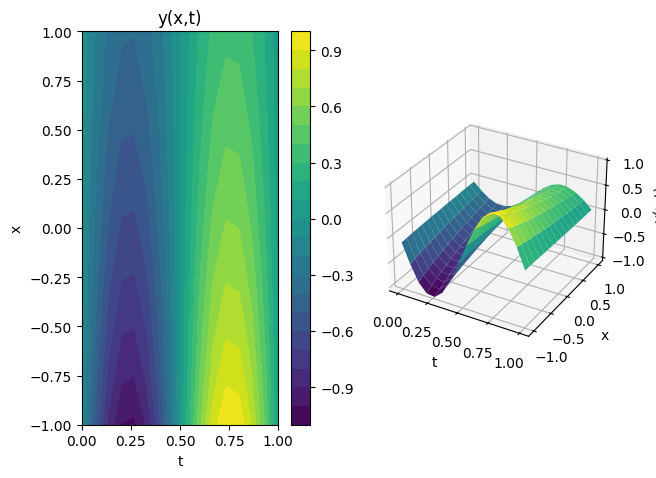

In [51]:
# plot FNO solution
# X-coordinates (index 0)
X_plot = XT_test_grid.squeeze(0)[0, :, :].detach().cpu()
# T-coordinates (index 1)
T_plot = XT_test_grid.squeeze(0)[1, :, :].detach().cpu()
plot3D(X_plot, T_plot, y_fno)

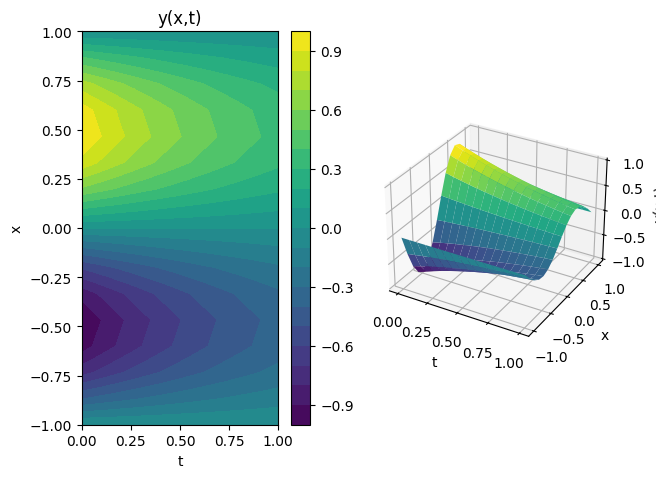

In [ ]:
# plot exact PDE solution
Y_plot = Y_test_grid.squeeze(0).squeeze(0).detach().cpu()
plot3D(X_plot, T_plot, Y_plot)

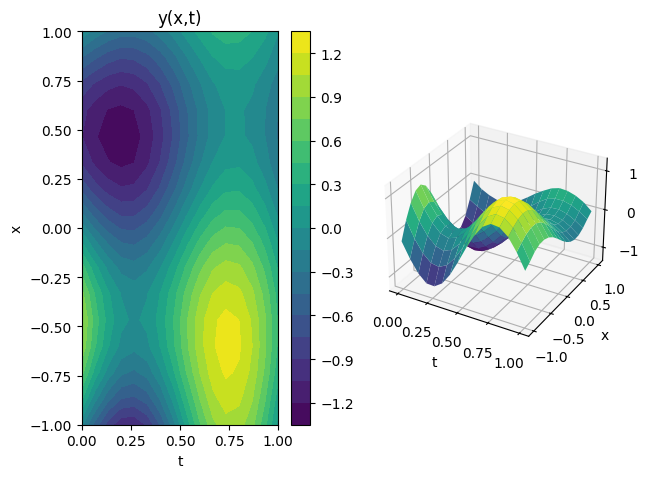

In [ ]:
# plot residuals PINN - exact PDE
plot3D(X_plot, T_plot, y_fno - Y_plot)